# RF Signals Augmentation Test Notebook

Test notebook for adding augmentation blocks using signals from the MATLAB waveform generator.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'gui'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.signal import hilbert

from augmentation import AugmentationPipeline, AWGNAugmentation, ScalarAmplitudeAndPhaseShift

## 1. Start MATLAB Engine and Generate a Signal

In [2]:
import matlab.engine

# Start MATLAB engine
print("Starting MATLAB engine...")
eng = matlab.engine.start_matlab()

# Add waveform functions to MATLAB path
waveform_path = str(project_root / 'gui' / 'waveform_functions')
eng.addpath(waveform_path)
print(f"Added MATLAB path: {waveform_path}")

Starting MATLAB engine...
Added MATLAB path: /Users/matthewxu/CursorProjects/FH11_RFML/gui/waveform_functions


In [15]:
from gui_elements import Waveform

'''
    Various waveforms to test
'''
waveform = Waveform(
    fs=48000,          # Sample rate: 48 kHz
    Tsymb=0.001,       # Symbol period: 1 ms
    Nsymb=1024,        # Number of symbols
    fc=6000,           # Carrier frequency: 6 kHz
    M=16,              # 16-QAM
    modulation="QAM",
    alpha=0.35,        # RRC roll-off
    span=8,            # Filter span
    pulse_shape='rrc',
    eng=eng
)

waveform = Waveform(
    fs=48000,
    Tsymb=0.001,
    Nsymb=1024,
    fc=6000,
    M=4,              # QPSK
    modulation="PSK",
    alpha=0.35,
    span=8,
    pulse_shape='rrc',
    eng=eng
)

# waveform = Waveform(
#     fs=48000,
#     Tsymb=0.002,      # Longer symbol period for FSK
#     Nsymb=512,
#     fc=12000,         # Higher carrier for FSK tones
#     M=8,              # 8 frequency tones
#     modulation="FSK",
#     alpha=0.35,
#     span=8,
#     pulse_shape='rrc',
#     eng=eng
# )

# waveform = Waveform(
#     fs=48000,
#     Tsymb=0.005,      # Longer dwell time per hop
#     Nsymb=256,
#     fc=12000,
#     M=8,              # 8 hopping channels
#     modulation="FHSS",
#     alpha=0.35,
#     span=8,
#     pulse_shape='rrc',
#     eng=eng
# )

# Generate the clean signal
waveform.generate_data()
clean_signal = waveform.get_data()

print(f"Generated {waveform.modulation}-{waveform.M} signal:")
print(f"  Samples: {len(clean_signal)}")
print(f"  Duration: {len(clean_signal)/waveform.fs*1000:.1f} ms")
print(f"  Samples per symbol: {waveform.sps}")

Generated PSK-4 signal:
  Samples: 49152
  Duration: 1024.0 ms
  Samples per symbol: 48


## 2. Create Augmentation Pipeline

In [16]:
# snr_db = 15
# mild = AugmentationPipeline([
#     ScalarAmplitudeAndPhaseShift(amplitude=0.9, phi=0.25 * np.pi),
#     AWGNAugmentation(snr_db=snr_db),
# ])


snr_db = 15
heavy = AugmentationPipeline([
    ScalarAmplitudeAndPhaseShift(amplitude=0.4, phi=1.5 * np.pi),
    AWGNAugmentation(snr_db=snr_db),
])


noisy_signal = heavy(clean_signal, waveform.fs)

### 2.5 Plotting cell

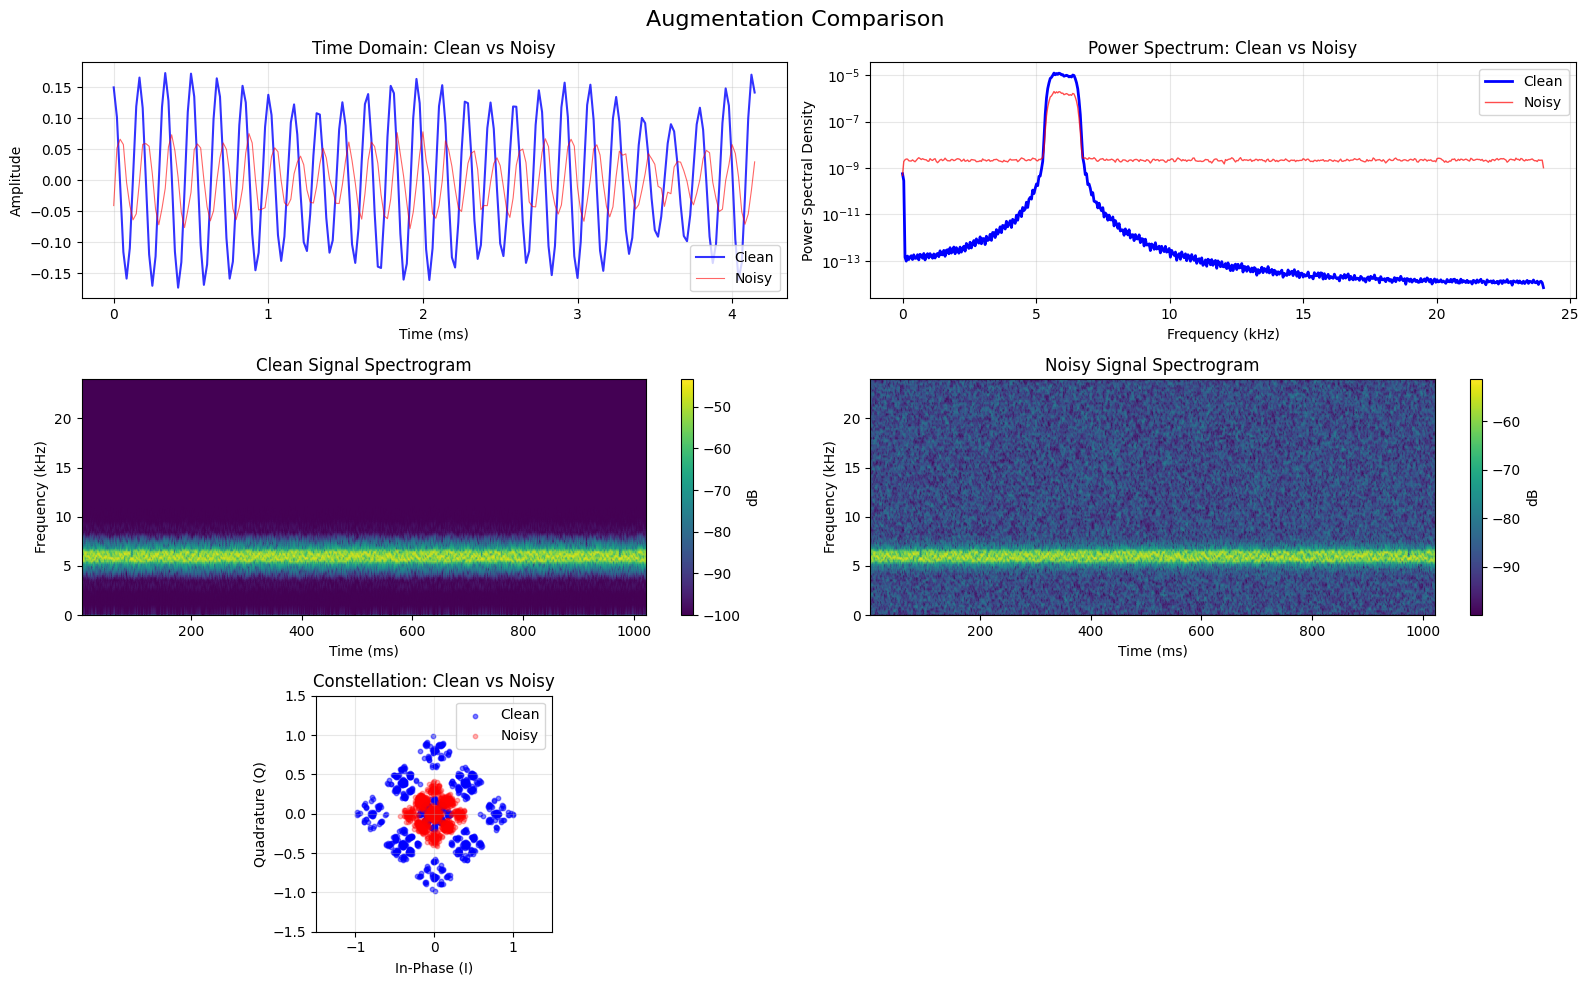

In [17]:
# Helper to extract I/Q from real passband signal
def extract_iq(signal, fs, fc, sps):
    """Downconvert real passband signal to complex baseband I/Q."""
    t = np.arange(len(signal)) / fs
    # Downconvert
    I = signal * 2 * np.cos(2 * np.pi * fc * t)
    Q = signal * -2 * np.sin(2 * np.pi * fc * t)
    # Low-pass filter
    from scipy.signal import butter, filtfilt
    b, a = butter(5, fc / (fs / 2), btype='low')
    I = filtfilt(b, a, I)
    Q = filtfilt(b, a, Q)
    # Decimate to symbol rate
    I_symb = I[sps//2::sps]
    Q_symb = Q[sps//2::sps]
    return I_symb, Q_symb

fig = plt.figure(figsize=(16, 10))
fig.suptitle(f'Augmentation Comparison', fontsize=16)

# Subplot 1: Time domain overlay (clean vs noisy)
ax1 = fig.add_subplot(3, 2, 1)
n_samples = 200  # Zoom in to see detail
t = np.arange(n_samples) / waveform.fs * 1000
ax1.plot(t, clean_signal[:n_samples], 'b-', linewidth=1.5, label='Clean', alpha=0.8)
ax1.plot(t, noisy_signal[:n_samples], 'r-', linewidth=0.8, label='Noisy', alpha=0.6)
ax1.set_title('Time Domain: Clean vs Noisy')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Power spectrum overlay (clean vs noisy)
ax2 = fig.add_subplot(3, 2, 2)
f_clean, psd_clean = scipy_signal.welch(clean_signal, waveform.fs, nperseg=1024)
f_noisy, psd_noisy = scipy_signal.welch(noisy_signal, waveform.fs, nperseg=1024)
ax2.semilogy(f_clean / 1000, psd_clean, 'b-', linewidth=2, label='Clean')
ax2.semilogy(f_noisy / 1000, psd_noisy, 'r-', linewidth=1, alpha=0.7, label='Noisy')
ax2.set_title('Power Spectrum: Clean vs Noisy')
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Power Spectral Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Clean signal spectrogram
ax3 = fig.add_subplot(3, 2, 3)
f_spec, t_spec, Sxx_clean = scipy_signal.spectrogram(clean_signal, waveform.fs, nperseg=256, noverlap=200)
im3 = ax3.pcolormesh(t_spec * 1000, f_spec / 1000, 10 * np.log10(Sxx_clean + 1e-10),
                     shading='gouraud', cmap='viridis')
ax3.set_title('Clean Signal Spectrogram')
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Frequency (kHz)')
plt.colorbar(im3, ax=ax3, label='dB')

# Subplot 4: Noisy signal spectrogram
ax4 = fig.add_subplot(3, 2, 4)
f_spec, t_spec, Sxx_noisy = scipy_signal.spectrogram(noisy_signal, waveform.fs, nperseg=256, noverlap=200)
im4 = ax4.pcolormesh(t_spec * 1000, f_spec / 1000, 10 * np.log10(Sxx_noisy + 1e-10),
                     shading='gouraud', cmap='viridis')
ax4.set_title('Noisy Signal Spectrogram')
ax4.set_xlabel('Time (ms)')
ax4.set_ylabel('Frequency (kHz)')
plt.colorbar(im4, ax=ax4, label='dB')

# Subplot 5: Constellation diagram (clean vs noisy)
ax5 = fig.add_subplot(3, 2, 5)

I_clean, Q_clean = extract_iq(clean_signal, waveform.fs, waveform.fc, waveform.sps)
I_noisy, Q_noisy = extract_iq(noisy_signal, waveform.fs, waveform.fc, waveform.sps)
# Normalize
scale = np.max(np.abs(I_clean + 1j * Q_clean))
I_clean, Q_clean = I_clean / scale, Q_clean / scale
I_noisy, Q_noisy = I_noisy / scale, Q_noisy / scale
# Plot
ax5.scatter(I_clean, Q_clean, c='blue', s=10, alpha=0.5, label='Clean')
ax5.scatter(I_noisy, Q_noisy, c='red', s=10, alpha=0.3, label='Noisy')
ax5.set_title('Constellation: Clean vs Noisy')
ax5.set_xlabel('In-Phase (I)')
ax5.set_ylabel('Quadrature (Q)')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_aspect('equal')
ax5.set_xlim(-1.5, 1.5)
ax5.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

## 3. Cleanup

In [ ]:
eng.quit()
print("MATLAB engine stopped.")